<a href="https://colab.research.google.com/github/animesh-11/AI_ML/blob/main/K_Means_Clustring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instructions
Here are some instructions you need to follow to obtain the correct answers:



For questions 1, 2, and 3:

Use only the provided dataset
Scale the features using StandardScaler() from sklearn.preprocessing
Apply K-means clustering using KMeans() from sklearn.cluster with the following settings:
Set init = 'random' (this will make it so that the initial centroids are randomly assigned)
Set random_state = 9001 (this will allow us to compare your results with our own)
Set n_init = 20 (as we are going for randomly assigned initial centroids, this will make it so that the algorithm runs twenty times with the best output in terms of inertial being displayed)
Search for K in {2, 3, 4, 5, 6}
For each K, fit the model on the scaled features and compute
Inertia (WCSS)
Average silhouette score; you may use use silhouette_score() from sklearn.metrics to obtain this
Elbow check: compute the drop in inertia for all K values and identify the largest drop across the tested values; this is the optimal K value using the elbow method
For each K value, report the cluster counts (number of samples per cluster)

# Task
Perform K-means clustering on the "carprices.csv" dataset. Load the dataset, preprocess it by selecting relevant features and scaling them using `StandardScaler()`. Then, apply `KMeans()` for K values from 2 to 6, with `init='random'`, `random_state=9001`, and `n_init=20`. For each K, compute the inertia (WCSS), average silhouette score, and cluster counts. Determine the optimal K using the elbow method by identifying the largest drop in inertia. Visualize the inertia and silhouette scores against K, and finally, summarize all clustering results, including the optimal K.

## Load Dataset

### Subtask:
Load the 'carprices.csv' dataset into a pandas DataFrame.


**Reasoning**:
First, I will import the pandas library to enable data manipulation. Then, I will load the 'carprices.csv' dataset into a DataFrame using `pd.read_csv()`. Finally, I will display the first few rows and the DataFrame's information to get an initial understanding of its structure and content, as per the instructions.



In [1]:
import pandas as pd

df = pd.read_csv('/content/carprices.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:
   enginesize  horsepower  citympg  highwaympg
0         130         111       21          27
1         130         111       21          27
2         152         154       19          26
3         109         102       24          30
4         136         115       18          22

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   enginesize  205 non-null    int64
 1   horsepower  205 non-null    int64
 2   citympg     205 non-null    int64
 3   highwaympg  205 non-null    int64
dtypes: int64(4)
memory usage: 6.5 KB


## Prepare Features for Clustering

### Subtask:
Identify and select the features from the dataset that will be used for K-means clustering. This step will also handle any necessary data cleaning or preprocessing, such as dropping non-numeric columns if present, ensuring only relevant features are used as per the instruction to 'Use only the provided dataset'.


**Reasoning**:
Based on the `df.info()` output from the previous step, all columns (`enginesize`, `horsepower`, `citympg`, `highwaympg`) are numerical and suitable for K-means clustering. I will select these columns and assign them to a new variable `X` for further processing.



In [2]:
X = df[['enginesize', 'horsepower', 'citympg', 'highwaympg']]

print("Selected features for clustering (X):")
print(X.head())

Selected features for clustering (X):
   enginesize  horsepower  citympg  highwaympg
0         130         111       21          27
1         130         111       21          27
2         152         154       19          26
3         109         102       24          30
4         136         115       18          22


## Scale Features

### Subtask:
Apply StandardScaler() from sklearn.preprocessing to scale the selected features. This is crucial for K-means as it relies on distance calculations.


**Reasoning**:
First, I will import the `StandardScaler` from `sklearn.preprocessing`. Then, I will instantiate `StandardScaler`, fit it to the `X` DataFrame, and transform the data, storing the scaled features in `X_scaled`. Finally, I will convert `X_scaled` back into a pandas DataFrame to maintain column labels for clarity.



In [3]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame, preserving column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("First 5 rows of scaled features (X_scaled):")
print(X_scaled.head())

First 5 rows of scaled features (X_scaled):
   enginesize  horsepower   citympg  highwaympg
0    0.074449    0.174483 -0.646553   -0.546059
1    0.074449    0.174483 -0.646553   -0.546059
2    0.604046    1.264536 -0.953012   -0.691627
3   -0.431076   -0.053668 -0.186865   -0.109354
4    0.218885    0.275883 -1.106241   -1.273900


## Perform K-means Clustering and Evaluate

### Subtask:
Iterate through K values from 2 to 6. For each K, apply KMeans() with init='random', random_state=9001, and n_init=20. Calculate and store the inertia (WCSS), average silhouette score using silhouette_score() from sklearn.metrics, and the cluster counts (number of samples per cluster).


**Reasoning**:
I will import the necessary libraries, initialize lists to store the results, and then iterate through the specified K values to perform K-means clustering, calculate inertia, silhouette scores, and cluster counts, storing these results in their respective lists.



In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Initialize empty lists to store results
inertias = []
silhouette_scores = []
cluster_counts = []

# Iterate through K values from 2 to 6
for K in range(2, 7):
    # Instantiate KMeans model
    kmeans_model = KMeans(n_clusters=K, init='random', random_state=9001, n_init=20)

    # Fit the model to the scaled data
    kmeans_model.fit(X_scaled)

    # Store inertia (WCSS)
    inertias.append(kmeans_model.inertia_)

    # Calculate and store silhouette score
    silhouette_avg = silhouette_score(X_scaled, kmeans_model.labels_)
    silhouette_scores.append(silhouette_avg)

    # Calculate and store cluster counts
    counts = pd.Series(kmeans_model.labels_).value_counts().sort_index()
    cluster_counts.append(counts.to_dict()) # Store as dictionary for readability

print("Inertia (WCSS) for each K:")
for k_val, inertia_val in zip(range(2, 7), inertias):
    print(f"K={k_val}: {inertia_val:.2f}")

print("\nAverage Silhouette Scores for each K:")
for k_val, silhouette_val in zip(range(2, 7), silhouette_scores):
    print(f"K={k_val}: {silhouette_val:.2f}")

print("\nCluster Counts for each K:")
for k_val, counts_dict in zip(range(2, 7), cluster_counts):
    print(f"K={k_val}: {counts_dict}")

Inertia (WCSS) for each K:
K=2: 385.23
K=3: 234.45
K=4: 174.14
K=5: 133.71
K=6: 111.62

Average Silhouette Scores for each K:
K=2: 0.47
K=3: 0.45
K=4: 0.43
K=5: 0.42
K=6: 0.41

Cluster Counts for each K:
K=2: {0: 85, 1: 120}
K=3: {0: 61, 1: 98, 2: 46}
K=4: {0: 15, 1: 41, 2: 88, 3: 61}
K=5: {0: 15, 1: 52, 2: 41, 3: 80, 4: 17}
K=6: {0: 15, 1: 46, 2: 63, 3: 17, 4: 33, 5: 31}


## Determine Optimal K using Elbow Method

### Subtask:
Compute the drop in inertia for each K value and identify the largest drop across the tested values. This will determine the optimal K value based on the elbow method.


**Reasoning**:
I will calculate the drop in inertia between consecutive K values, identify the largest drop, and determine the optimal K. I will then print the inertia drops and the optimal K value.



In [5]:
inertia_drops = []
# K values range from 2 to 6, so inertias are indexed 0 (K=2) to 4 (K=6)
# We need to calculate drops from K=3 onwards relative to K-1
# inertia_drops[0] will be for K=3 (inertia[0] - inertia[1]) which is inertia(K=2) - inertia(K=3)
for i in range(len(inertias) - 1):
    drop = inertias[i] - inertias[i+1]
    inertia_drops.append(drop)

# Find the K value corresponding to the largest drop
# K values start from 2. The drops are calculated for K=3 (index 0 of inertia_drops), K=4 (index 1), etc.
# So, if max_drop_index is 0, optimal K is 3.
# optimal_k = (index of largest drop) + 3
if inertia_drops:
    max_drop_index = inertia_drops.index(max(inertia_drops))
    optimal_k_elbow = (max_drop_index + 1) + 2 # +1 because inertias are 0-indexed, +2 because first drop is for K=3
else:
    optimal_k_elbow = None

print("\nInertia Drops (WCSS):")
for i, drop in enumerate(inertia_drops):
    # The first drop is for K=3 (from K=2 to K=3), second for K=4, etc.
    print(f"Drop from K={i+2} to K={i+3}: {drop:.2f}")

print(f"\nOptimal K using Elbow Method (largest inertia drop): {optimal_k_elbow}")


Inertia Drops (WCSS):
Drop from K=2 to K=3: 150.78
Drop from K=3 to K=4: 60.31
Drop from K=4 to K=5: 40.43
Drop from K=5 to K=6: 22.09

Optimal K using Elbow Method (largest inertia drop): 3


## Visualize Clustering Metrics

### Subtask:
Generate plots to visualize the inertia and average silhouette scores against the number of clusters (K). This visualization will help in understanding the elbow method and silhouette analysis, with clear legends for each plot.


**Reasoning**:
I will import `matplotlib.pyplot` to generate the plots. Then, I will create a list of K values and use this list along with the previously calculated `inertias` and `silhouette_scores` to create two line plots. Each plot will have appropriate labels, titles, and legends to visualize the elbow method and silhouette analysis effectively.



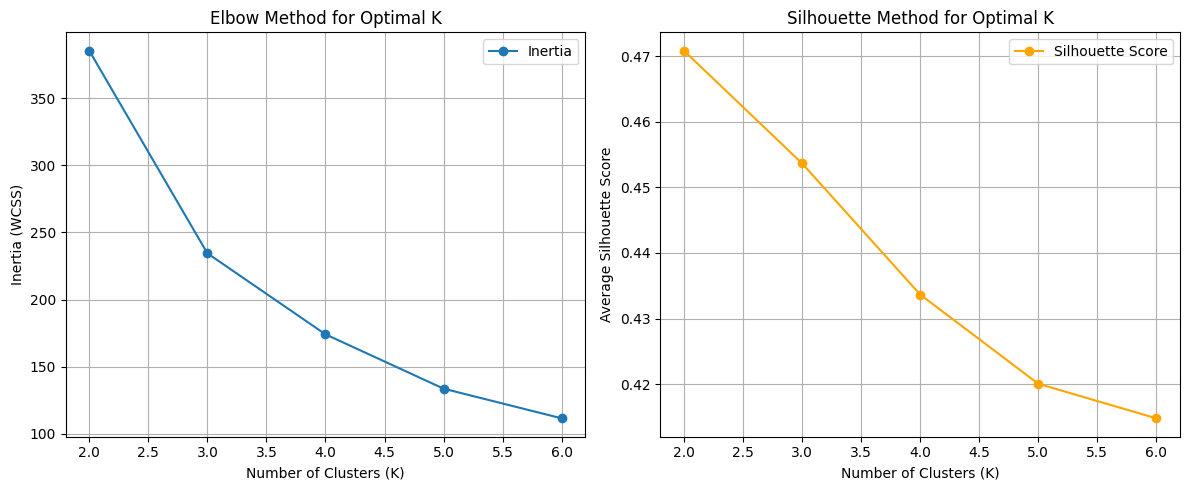

In [6]:
import matplotlib.pyplot as plt

# Create a list of K values
k_values = list(range(2, 7))

# Plotting Inertia (WCSS)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(k_values, inertias, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.legend(['Inertia'])
plt.grid(True)

# Plotting Average Silhouette Scores
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='orange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Method for Optimal K')
plt.legend(['Silhouette Score'])
plt.grid(True)

plt.tight_layout()
plt.show()

## Report Results

### Subtask:
Present a summary of the clustering results for each K, including inertia, average silhouette score, cluster counts, and the identified optimal K value from the elbow method.


## Report Results

### Subtask:
Present a summary of the clustering results for each K, including inertia, average silhouette score, cluster counts, and the identified optimal K value from the elbow method.

#### Instructions
1. Print the K values (from 2 to 6) along with their corresponding inertia, average silhouette score, and cluster counts in a clear, formatted way.
2. Explicitly state the optimal K value identified by the elbow method.

**Reasoning**:
The subtask is to report the clustering results and the optimal K value. I will generate a code block to print a clear summary of the inertia, silhouette scores, and cluster counts for each K, and then explicitly state the optimal K determined by the elbow method.



In [7]:
print("\n--- Clustering Results Summary ---")
for i, K in enumerate(k_values):
    print(f"\nFor K = {K}:")
    print(f"  Inertia (WCSS): {inertias[i]:.2f}")
    print(f"  Average Silhouette Score: {silhouette_scores[i]:.2f}")
    print(f"  Cluster Counts: {cluster_counts[i]}")

print(f"\nOptimal K value identified by the Elbow Method: {optimal_k_elbow}")


--- Clustering Results Summary ---

For K = 2:
  Inertia (WCSS): 385.23
  Average Silhouette Score: 0.47
  Cluster Counts: {0: 85, 1: 120}

For K = 3:
  Inertia (WCSS): 234.45
  Average Silhouette Score: 0.45
  Cluster Counts: {0: 61, 1: 98, 2: 46}

For K = 4:
  Inertia (WCSS): 174.14
  Average Silhouette Score: 0.43
  Cluster Counts: {0: 15, 1: 41, 2: 88, 3: 61}

For K = 5:
  Inertia (WCSS): 133.71
  Average Silhouette Score: 0.42
  Cluster Counts: {0: 15, 1: 52, 2: 41, 3: 80, 4: 17}

For K = 6:
  Inertia (WCSS): 111.62
  Average Silhouette Score: 0.41
  Cluster Counts: {0: 15, 1: 46, 2: 63, 3: 17, 4: 33, 5: 31}

Optimal K value identified by the Elbow Method: 3


## Final Task

### Subtask:
Summarize the findings and the optimal number of clusters for the dataset based on the analysis.


## Summary:

### Q&A
The optimal number of clusters for the dataset based on the analysis is 3.

### Data Analysis Key Findings
*   The dataset, 'carprices.csv', contains 205 entries with 4 relevant numerical features: 'enginesize', 'horsepower', 'citympg', and 'highwaympg'. These features were successfully scaled using `StandardScaler` for clustering.
*   The inertia (Within-Cluster Sum of Squares, WCSS) consistently decreased as the number of clusters (K) increased, from 385.23 at K=2 to 111.62 at K=6.
*   The largest drop in inertia was observed when K increased from 2 to 3, with a significant decrease of 150.78 (from 385.23 to 234.45). This identifies K=3 as the optimal number of clusters according to the elbow method.
*   The average silhouette score was highest at K=2 (0.47), slightly decreasing to 0.45 at K=3, and further to 0.41 at K=6. While K=2 had the highest silhouette score, the elbow method strongly indicated K=3.
*   For the optimal K=3, the data was segmented into three clusters with 61, 98, and 46 samples, respectively.

### Insights or Next Steps
*   K=3 provides a good balance between reducing within-cluster variance and limiting the complexity of the model, as indicated by the significant "elbow" in the inertia plot and the second-highest silhouette score.
*   Further investigation could involve analyzing the characteristics of the three clusters identified at K=3 (e.g., mean 'enginesize', 'horsepower', 'citympg', 'highwaympg' for each cluster) to understand the underlying car segments.
